Accuracy: 0.998
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      3422
           1       1.00      1.00      1.00      6578

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000

Saved tree image.


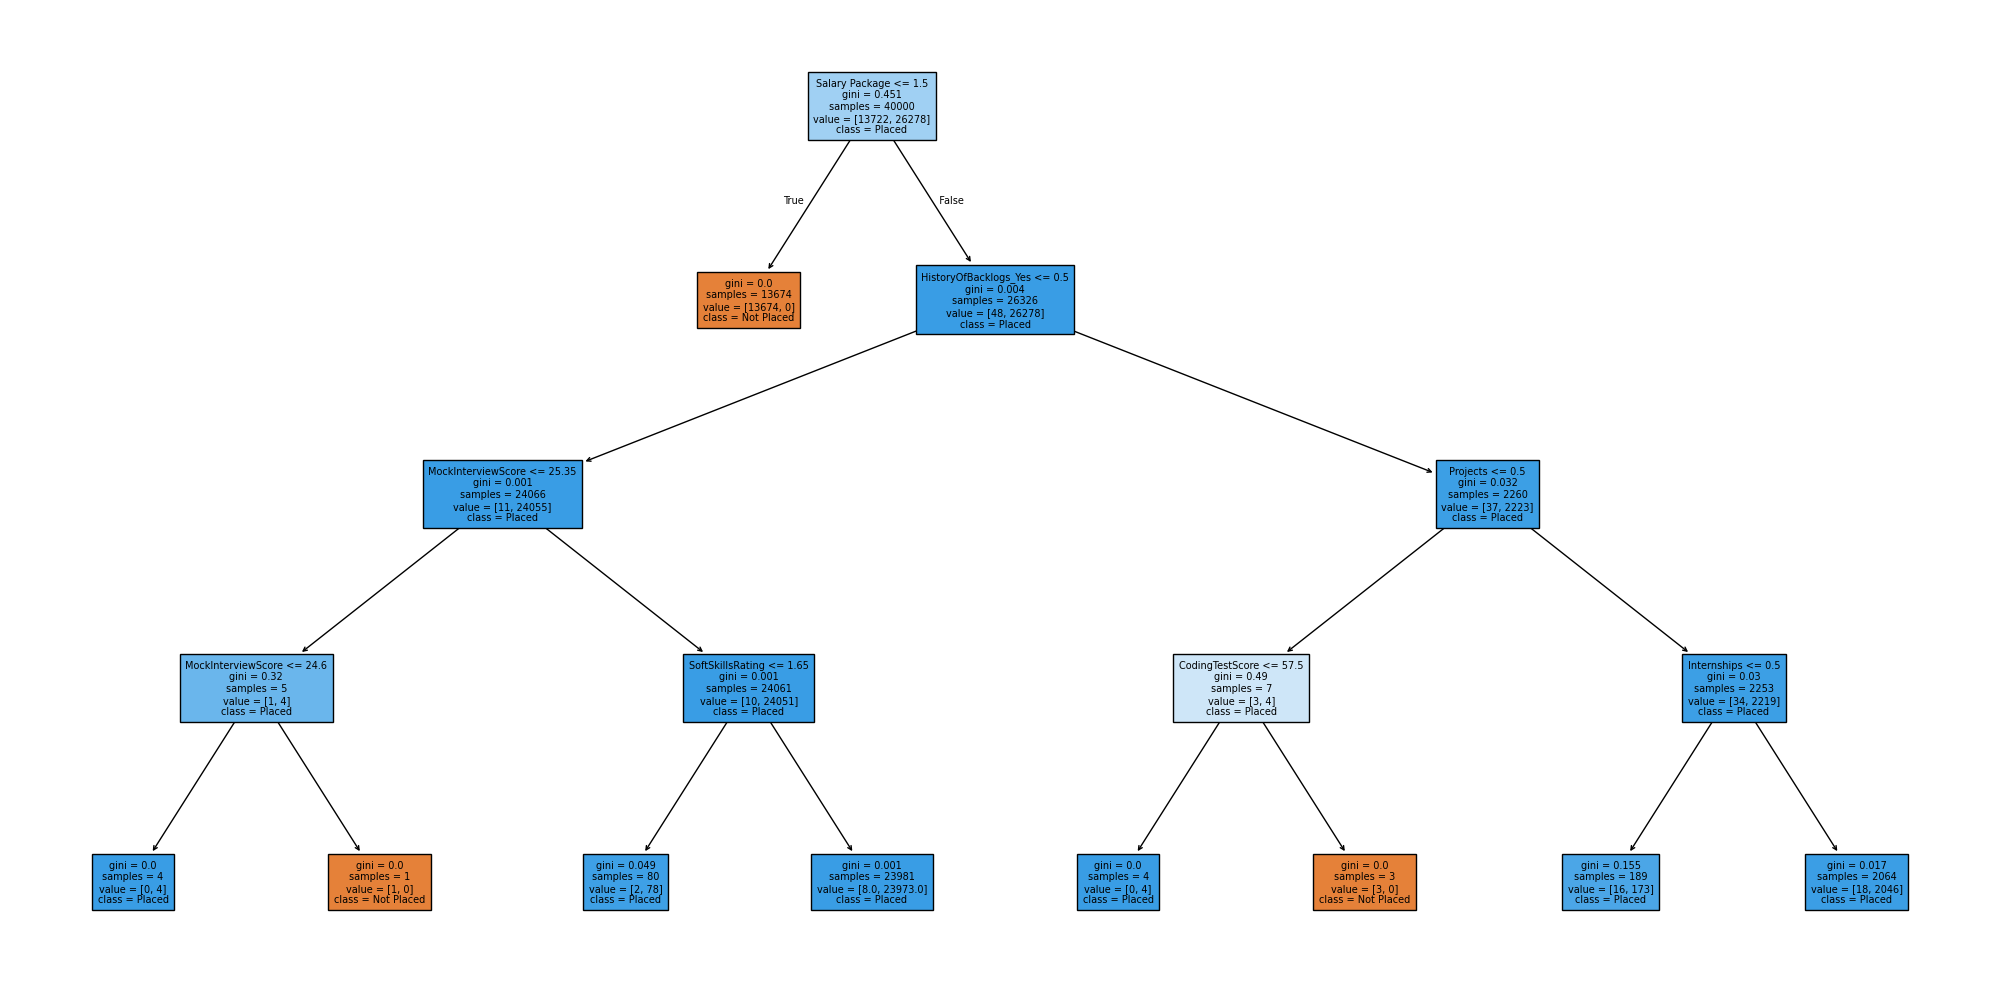

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

df = pd.read_csv('placement_predict_50k_adjusted.csv')
df = df.drop(columns=['IsAnomaly'])

for col in df.columns:
  if pd.api.types.is_numeric_dtype(df[col]):
    df[col] = df[col].fillna(df[col].median())
  else:
    df[col] = df[col].fillna(df[col].mode()[0])

# Automatically encode all categorical/object columns instead of hardcoding a list
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop(columns=['PlacementStatus'])
y = df_encoded['PlacementStatus']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

plt.figure(figsize=(20, 10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Not Placed', 'Placed'],
    filled=True,
    fontsize=7,
)
plt.tight_layout()
plt.savefig('decision_tree.png', dpi=150)
print('Saved tree image.')